# **📊 EXPLORATORY DATA ANALYSIS**

### **IMPORTING MODULES AND CUSTOM FUNCTIONS**

In [1]:
# Accessing the OS
import os
os.makedirs("Plots", exist_ok=True)

# Colorfull outputs
import io 
from rich.console import Console
console = Console()

# can't print colorful .info() wihout this
def dataset_info(df):
    buffer = io.StringIO()
    df.info(buf=buffer)

    console.print(buffer.getvalue())

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

from pathlib import Path

EDA_plots_dir = Path("Plots")
EDA_plots_dir.mkdir(exist_ok=True)

# Custom function for saving plots to specific directory
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(EDA_plots_dir / filename, dpi=300, bbox_inches="tight")

### **LOADING DATASET**

In [2]:
data = pd.read_csv(r"..\Processed Datasets\processed_data_eda.csv")
df=pd.DataFrame(data)
df.head(10)


,tag,pattern,response,pattern_length,response_length
0,greeting,Hi,Hello! How can I assist you with Medical Assis...,1,10
1,greeting,Hello,Hello! How can I assist you with Medical Assis...,1,10
2,greeting,Hey,Hello! How can I assist you with Medical Assis...,1,10
3,greeting,Greetings,Hello! How can I assist you with Medical Assis...,1,10
4,greeting,Hi there,Hello! How can I assist you with Medical Assis...,2,10
5,greeting,Good morning,Hello! How can I assist you with Medical Assis...,2,10
6,greeting,Hey Assistant,Hello! How can I assist you with Medical Assis...,2,10
7,greeting,Yo,Hello! How can I assist you with Medical Assis...,1,10
8,cancer_general,What is cancer?,Cancer is a group of diseases characterized by...,3,40
9,cancer_general,Tell me about cancer,Cancer is a group of diseases characterized by...,4,40


In [3]:
console.print(f"Dataset Shape: {df.shape}")
dataset_info(df)

Dataset Shape: (166, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   tag              166 non-null    object
 1   pattern          166 non-null    object
 2   response         166 non-null    object
 3   pattern_length   166 non-null    int64 
 4   response_length  166 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 6.6+ KB

### **ANY MISSING VALUES**

In [4]:
if (df.isnull().sum().any()):
    console.print(f"No. of Missing Values: [bold red]{df.isnull().sum().sum()}")
else:
    console.print("[bold green]NO MISSING VALUE")

NO MISSING VALUE

### **ANY DUPLICATE VALUES**

In [5]:
# 1. Check for entire duplicate rows
if df.duplicated().any():
    console.print(f"Duplicate Rows Found: [bold red]{df.duplicated().sum()}")
else:
    console.print("[bold green]NO DUPLICATE ROWS")


NO DUPLICATE ROWS

### **NUMBER OF PATTERN ANALYSIS PER INTENT**

In [6]:
console.print(df['tag'].value_counts())

tag
greeting                   8
diabetes_prevention        8
stroke_prevention          8
stroke_types               8
hypertension_prevention    8
hypertension_types         8
alzheimers_prevention      8
alzheimers_types           8
alzheimers_symptoms        8
diabetes_types             8
cancer_prevention          8
cancer_symptoms            8
cancer_types               8
send_off                   8
alzheimers_general         7
diabetes_symptoms          7
cancer_general             7
hypertension_general       7
diabetes_general           7
stroke_general             7
hypertension_symptoms      6
stroke_symptoms            6
Name: count, dtype: int64

Number of intents: 22 

 ['greeting' 'cancer_general' 'cancer_types' 'cancer_symptoms'
 'cancer_prevention' 'diabetes_general' 'diabetes_types'
 'diabetes_symptoms' 'diabetes_prevention' 'alzheimers_general'
 'alzheimers_types' 'alzheimers_symptoms' 'alzheimers_prevention'
 'hypertension_general' 'hypertension_types' 'hypertension_symptoms'
 'hypertension_prevention' 'stroke_general' 'stroke_types'
 'stroke_symptoms' 'stroke_prevention' 'send_off']

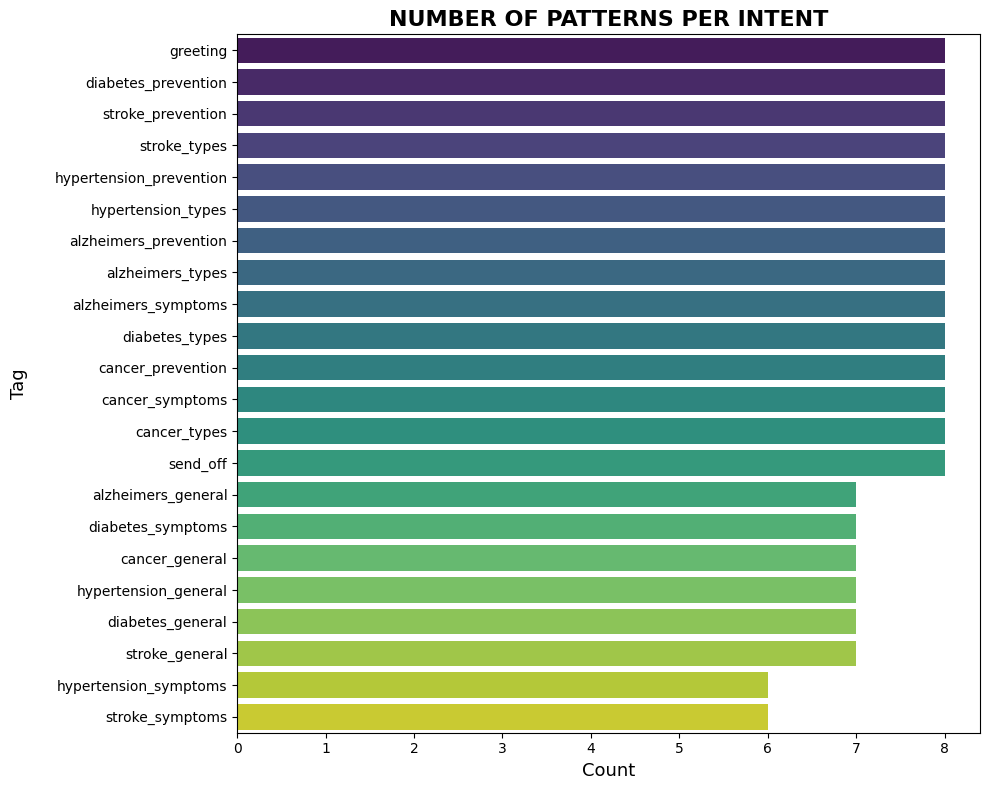

In [7]:
# total number of intents
console.print("Number of intents:", df["tag"].nunique(), "\n\n", df["tag"].unique())
console.print()

palette = sns.color_palette("viridis", n_colors=len(df['tag'].value_counts().index))

plt.figure(figsize=(10,8))
sns.barplot(x=df['tag'].value_counts().values, 
            y=df['tag'].value_counts().index,
            hue=df['tag'].value_counts().index,
            palette=palette)

plt.title("NUMBER OF PATTERNS PER INTENT", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=13)
plt.ylabel("Tag\n", fontsize=13)

save_plot("NUMBER OF PATTERNS PER INTENT")
plt.show()


###  **INTENTS GROUPED BY CATEGORY**

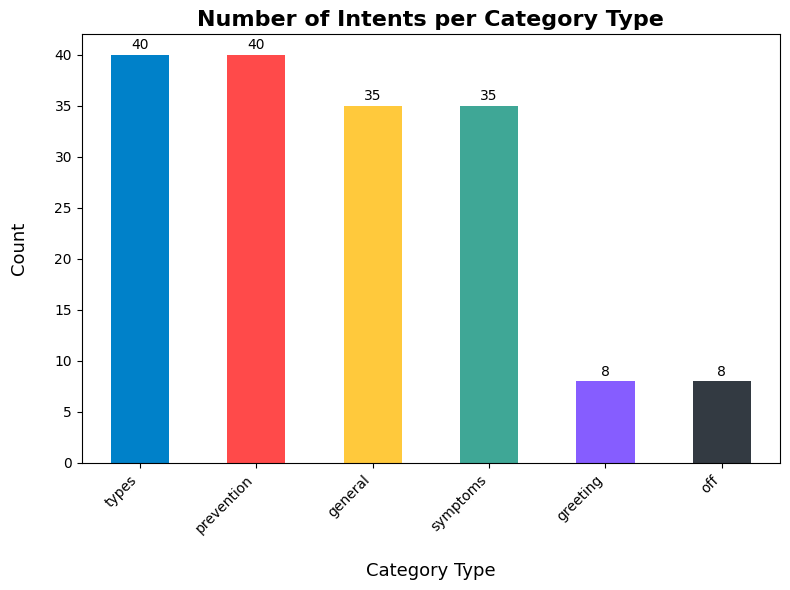

In [8]:
df['intent_type'] = df['tag'].apply(lambda x: x.split('_')[-1])
type_counts = df['intent_type'].value_counts()

plt.figure(figsize=(8, 6))

colors =['#0081C9', '#FF4A4A', '#FFC93C', '#3FA796', '#865DFF', '#333A42']
ax = type_counts.plot(kind='bar', color=colors)
ax.bar_label(ax.containers[0], padding=2)

plt.title('Number of Intents per Category Type', fontsize=16, fontweight='bold')
plt.xlabel('\nCategory Type', fontsize=13)
plt.ylabel('Count\n', fontsize=13)
plt.xticks(rotation=45, ha='right')

save_plot("NUMBER OF INTENTS PER CATEGORY TYPE")
plt.show()
plt.close()

###  **TEST LENGTH ANALYSIS**
**Examining how long the user queries *(patterns)* and bot replies *(responses)* are, using the pre-computed `pattern_length` and `response_length` columns.**

In [9]:
df[['pattern_length', 'response_length']].describe()

,pattern_length,response_length
count,166.000000,166.000000
mean,6.831325,42.313253
std,5.332165,24.300107
min,1.000000,8.000000
25%,4.000000,25.000000
50%,5.000000,35.000000
75%,7.000000,52.000000
max,29.000000,87.000000


tag
alzheimers_general          4.142857
alzheimers_prevention       6.875000
alzheimers_symptoms        16.250000
alzheimers_types            5.000000
cancer_general              4.142857
cancer_prevention           6.750000
cancer_symptoms            14.000000
cancer_types                5.250000
diabetes_general            3.857143
diabetes_prevention         6.750000
diabetes_symptoms           9.142857
diabetes_types              5.375000
greeting                    1.375000
hypertension_general        4.285714
hypertension_prevention     7.250000
hypertension_symptoms      14.166667
hypertension_types          5.125000
send_off                    2.250000
stroke_general              4.428571
stroke_prevention           7.000000
stroke_symptoms            14.000000
stroke_types                5.125000
Name: pattern_length, dtype: float64

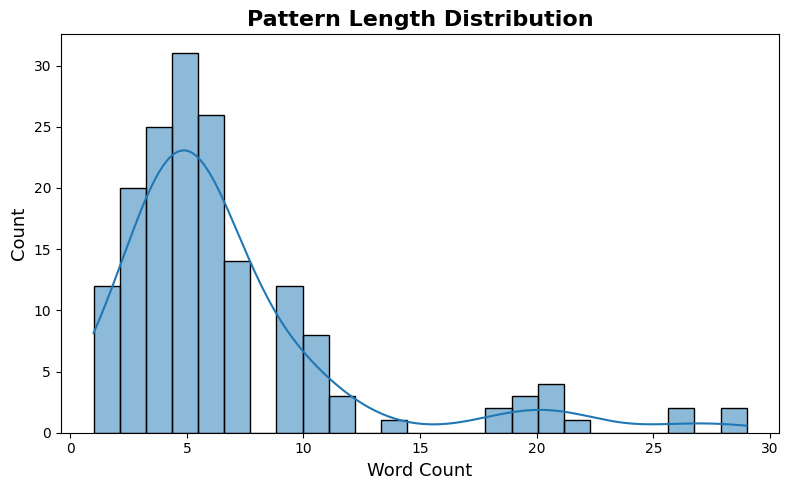

In [10]:
console.print(df.groupby("tag")["pattern_length"].mean())

plt.figure(figsize=(8,5))
sns.histplot(df['pattern_length'], 
             bins=25, 
             kde=True)
plt.title("Pattern Length Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Word Count", fontsize=13)
plt.ylabel("Count", fontsize=13)

save_plot("PATTERN LENGTH DISTRIBUTION")
plt.show()

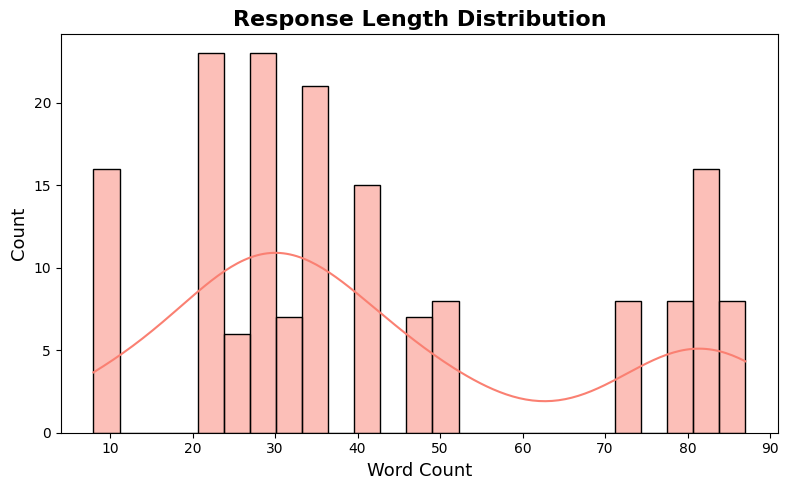

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['response_length'], bins=25, kde=True, color="salmon")
plt.title("Response Length Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Word Count", fontsize=13)
plt.ylabel("Count", fontsize=13)
save_plot("RESPONSE LENGTH DISTRIBUTION")
plt.show()

###  **PATTERN TO RESPONSE RATIO ANALYSIS**
**Examining the balance between user query variations *(pattern)* and bot reply variations *(response)* per intent, using the pre-computed `pattern` and `response` columns.**

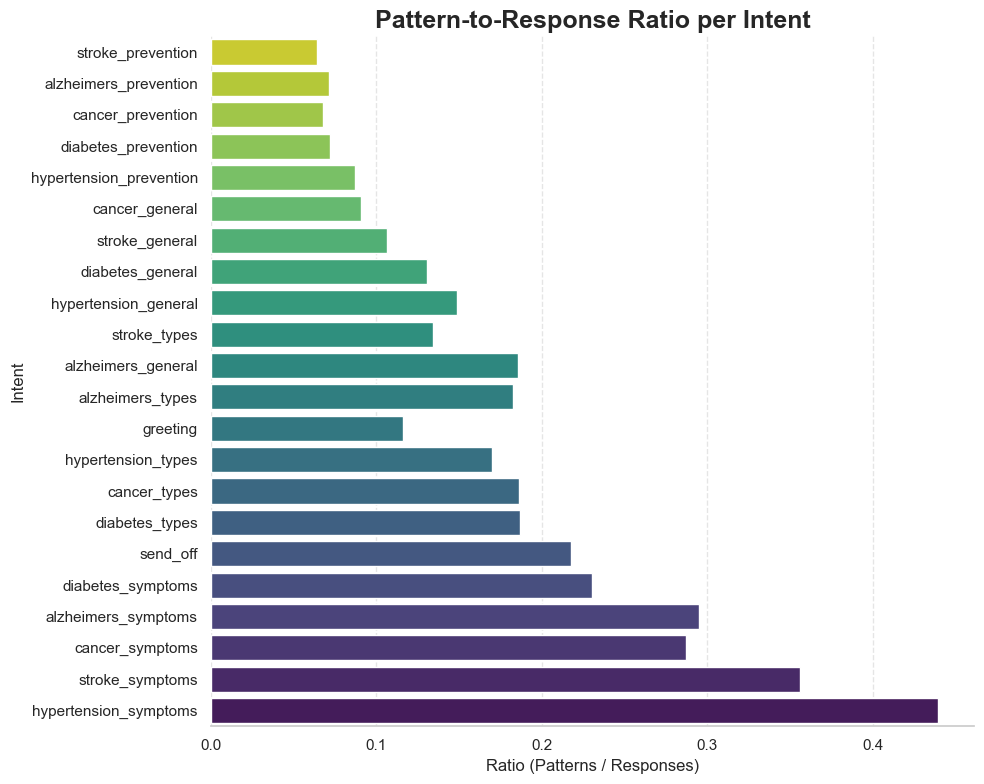

In [12]:
# ---------------------------
# Feature Engineering
# ---------------------------
df['num_patterns'] = df['pattern'].apply(len)
df['num_responses'] = df['response'].apply(len)

# Pattern-to-Response Ratio
df['ratio'] = df['num_patterns'] / df['num_responses']

# Sort by ratio (highest first)
df_sorted = df.sort_values(by='ratio', ascending=False)

# ---------------------------
# Plot
# ---------------------------
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))

sns.barplot(
    data=df_sorted,
    x='ratio',
    y='tag',
    hue='tag',          # Allows color palette
    palette='viridis',  # Change to 'mako', 'flare', 'crest', etc. if desired
    legend=False,
    errorbar=None       # Removes confidence interval/error bars
)

plt.title(
    'Pattern-to-Response Ratio per Intent',
    fontsize=18,
    fontweight='bold'
)
plt.xlabel('Ratio (Patterns / Responses)', fontsize=12)
plt.ylabel('Intent', fontsize=12)

# Grid only on x-axis
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Remove unnecessary borders
sns.despine(left=True, bottom=False)

# Highest ratio at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### MOST FREQUENT WORDS IN PATTERN
**Finding common vocabulary in user queries**

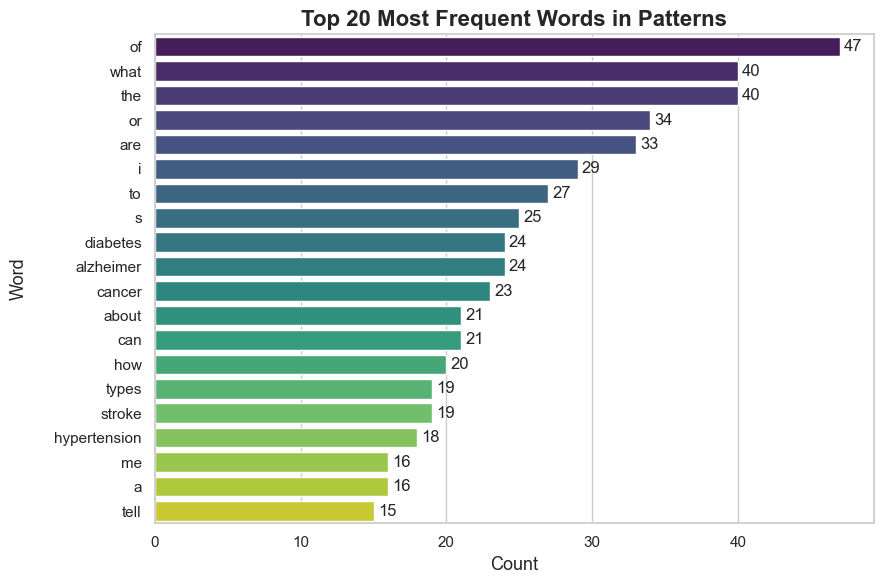

In [13]:
words = re.findall(r'\b[a-z]+\b', ' '.join(df['pattern']).lower())
top_words = Counter(words).most_common(20)
top_df = pd.DataFrame(top_words, columns=['word', 'count'])

plt.figure(figsize=(9, 6))

palette = sns.color_palette("viridis", n_colors=len(top_df))

ax = sns.barplot(data=top_df, 
                 x='count', 
                 y='word', 
                 palette=palette,
                 hue='word')

# Add count labels beside each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Top 20 Most Frequent Words in Patterns", fontsize=16, fontweight='bold')
plt.xlabel("Count", fontsize=13)
plt.ylabel('Word\n', fontsize=13)

save_plot("TOP 20 MOST FREQUENT WORDS IN PATTERNS")
plt.show()

##  **Summary of Findings**
- Dataset has **98 rows**, **22 intents**, **no missing values** or **duplicates**.
- Intent distribution is slightly **imbalanced** (3–5 examples per intent).
- Average **pattern length** and **response length** noted above.
- **Most frequent words** identified above